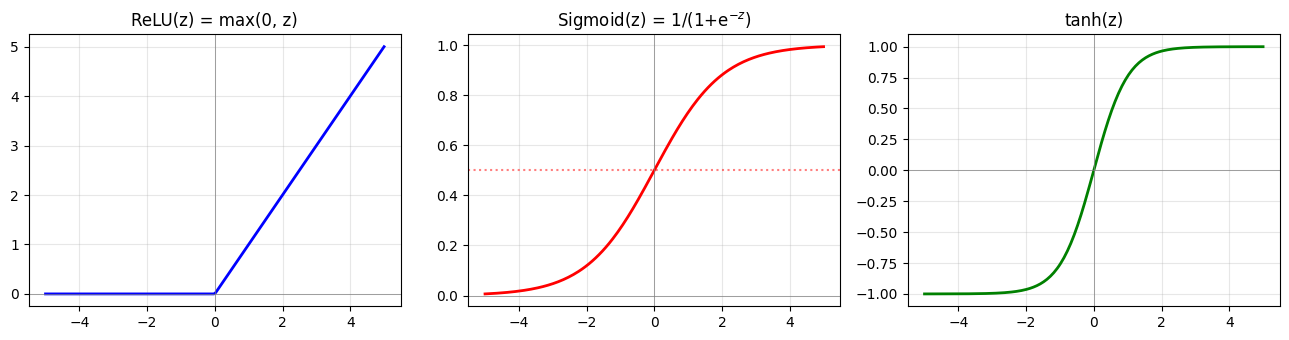

In [1]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 200)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].plot(z, np.maximum(0, z), color='blue', linewidth=2)
axes[0].set_title('ReLU(z) = max(0, z)'); axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='gray', lw=0.5); axes[0].axvline(0, color='gray', lw=0.5)

axes[1].plot(z, 1 / (1 + np.exp(-z)), color='red', linewidth=2)
axes[1].set_title(r'Sigmoid(z) = 1/(1+e$^{-z}$)'); axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)
axes[1].axhline(0.5, color='red', linestyle=':', alpha=0.5)

axes[2].plot(z, np.tanh(z), color='green', linewidth=2)
axes[2].set_title('tanh(z)'); axes[2].grid(alpha=0.3)
axes[2].axhline(0, color='gray', lw=0.5); axes[2].axvline(0, color='gray', lw=0.5)

plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

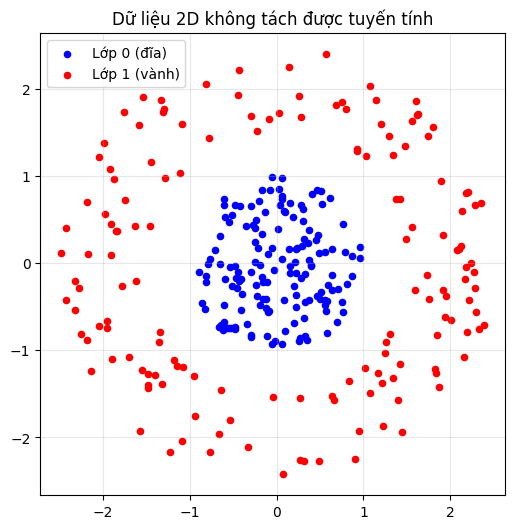

In [3]:
def gen_disk(n, r_max=1.0):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = r_max * np.sqrt(u)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

def gen_ring(n, r_in=1.5, r_out=2.5):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = np.sqrt(u * (r_out**2 - r_in**2) + r_in**2)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

n_per_class = 150
X0 = gen_disk(n_per_class)
X1 = gen_ring(n_per_class)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

plt.figure(figsize=(6, 6))
plt.scatter(X0[:, 0], X0[:, 1], color='blue', label='Lớp 0 (đĩa)', s=20)
plt.scatter(X1[:, 0], X1[:, 1], color='red',  label='Lớp 1 (vành)', s=20)
plt.legend(); plt.axis('equal'); plt.grid(alpha=0.3)
plt.title('Dữ liệu 2D không tách được tuyến tính')
plt.show()

In [4]:
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train = torch.FloatTensor(X_train_np)
y_train = torch.FloatTensor(y_train_np).unsqueeze(1)
X_test  = torch.FloatTensor(X_test_np)
y_test  = torch.FloatTensor(y_test_np).unsqueeze(1)

print(f'Train: {len(X_train)} điểm,  Test: {len(X_test)} điểm')

Train: 240 điểm,  Test: 60 điểm


In [5]:
logreg = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
opt_lr = optim.Adam(logreg.parameters(), lr=0.05)
for _ in range(300):
    opt_lr.zero_grad()
    loss = nn.BCELoss()(logreg(X_train), y_train)
    loss.backward(); opt_lr.step()

with torch.no_grad():
    pred = (logreg(X_test) > 0.5).float()
    acc_lr = (pred == y_test).float().mean().item()
print(f'Logistic regression accuracy: {acc_lr*100:.2f}%   (kỳ vọng quanh 50%)')

Logistic regression accuracy: 41.67%   (kỳ vọng quanh 50%)


In [6]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))

model = ANN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

ANN(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [29]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=500, lr=0.01,
                criterion_class=nn.BCELoss, optimizer_class=optim.Adam,
                predict_fn=lambda x: (x > 0.5).float(), optimizer_params={}):

    criterion = criterion_class()
    optimizer = optimizer_class(model.parameters(), lr=lr, **optimizer_params)

    loss_history, acc_history = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_pred = predict_fn(model(X_test))
            acc = (test_pred == y_test).float().mean().item()
        loss_history.append(loss.item())
        acc_history.append(acc)

    return loss_history, acc_history

### Huấn luyện mô hình gốc (4 nút ẩn)

Mô hình 4 nút ẩn - Loss cuối: 0.0198, Test Acc cuối: 100.00%


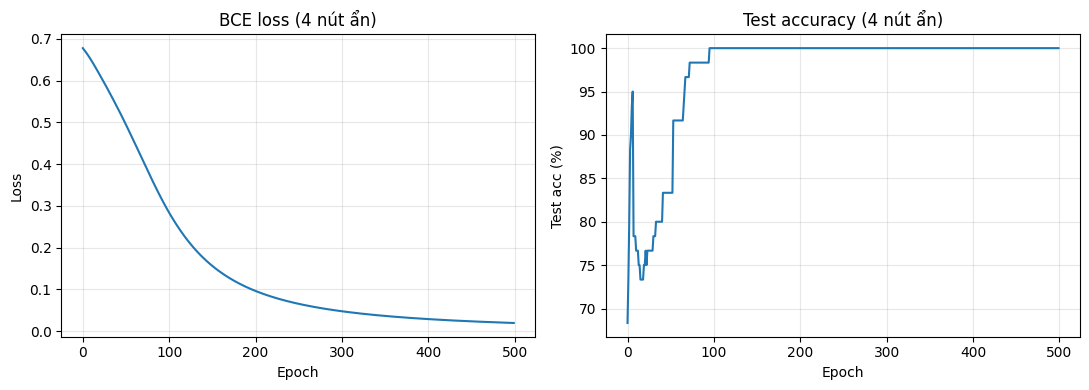

In [11]:
# Huấn luyện mô hình ANN gốc (4 nút ẩn)
model_4_nodes = ANN()
loss_history_4_nodes, acc_history_4_nodes = train_model(model_4_nodes, X_train, y_train, X_test, y_test, epochs=500, lr=0.01)

print(f'Mô hình 4 nút ẩn - Loss cuối: {loss_history_4_nodes[-1]:.4f}, Test Acc cuối: {acc_history_4_nodes[-1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history_4_nodes); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss (4 nút ẩn)')
axes[1].plot([a*100 for a in acc_history_4_nodes]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy (4 nút ẩn)')
plt.tight_layout(); plt.show()

Epoch  100/500  loss=0.0099  test_acc=100.00%
Epoch  200/500  loss=0.0071  test_acc=100.00%
Epoch  300/500  loss=0.0054  test_acc=100.00%
Epoch  400/500  loss=0.0043  test_acc=100.00%
Epoch  500/500  loss=0.0035  test_acc=100.00%


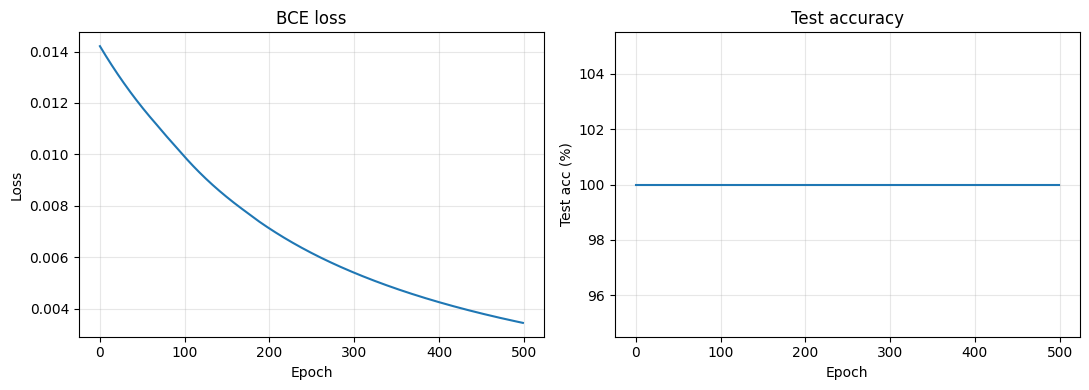

In [15]:
epochs = 500
loss_history, acc_history = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = (model(X_test) > 0.5).float()
        acc = (test_pred == y_test).float().mean().item()
    loss_history.append(loss.item())
    acc_history.append(acc)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{epochs}  loss={loss.item():.4f}  test_acc={acc*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss')
axes[1].plot([a*100 for a in acc_history]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()

In [8]:
model.eval()
with torch.no_grad():
    pred = (model(X_test) > 0.5).float()
    acc_ann = (pred == y_test).float().mean().item()
print(f'ANN final test accuracy: {acc_ann*100:.2f}%')
print(f'(Baseline LogReg đạt {acc_lr*100:.2f}% — ANN thắng đậm vì học được ranh giới phi tuyến.)')

ANN final test accuracy: 100.00%
(Baseline LogReg đạt 41.67% — ANN thắng đậm vì học được ranh giới phi tuyến.)


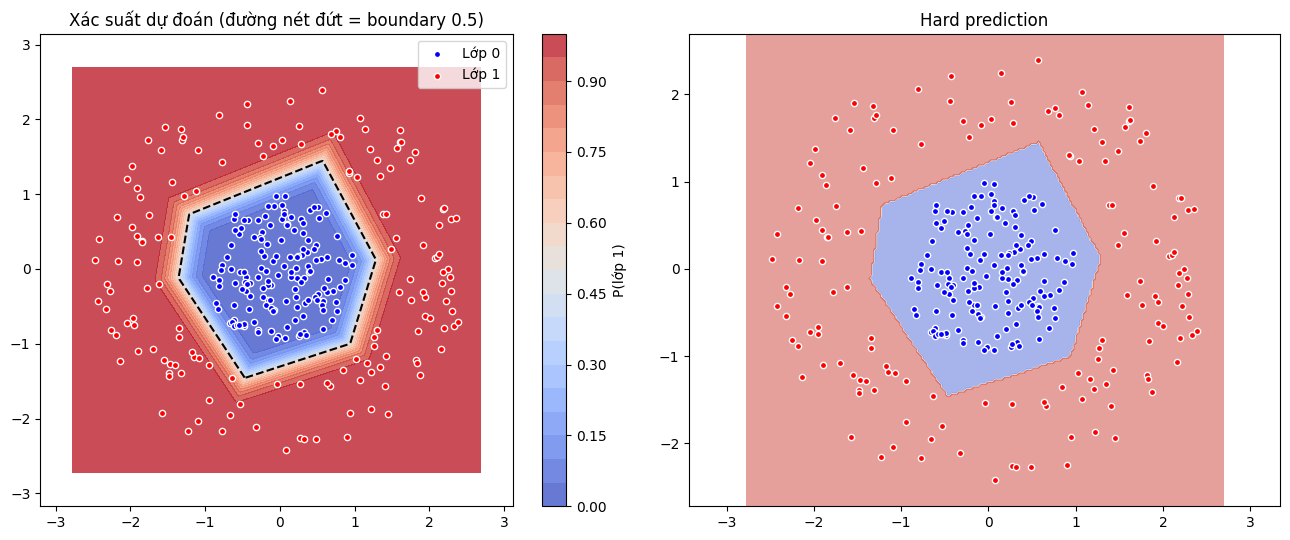

In [9]:
x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

model.eval()
with torch.no_grad():
    proba = model(grid).numpy().reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Bên trái: contour xác suất (mềm)
cs = axes[0].contourf(xx, yy, proba, levels=20, cmap='coolwarm', alpha=0.8)
axes[0].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20, label='Lớp 0')
axes[0].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20, label='Lớp 1')
axes[0].contour(xx, yy, proba, levels=[0.5], colors='black', linestyles='--')
plt.colorbar(cs, ax=axes[0], label='P(lớp 1)')
axes[0].set_title('Xác suất dự đoán (đường nét đứt = boundary 0.5)')
axes[0].axis('equal'); axes[0].legend()

# Bên phải: hard prediction
axes[1].contourf(xx, yy, (proba > 0.5).astype(int), alpha=0.5, cmap='coolwarm')
axes[1].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20)
axes[1].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20)
axes[1].set_title('Hard prediction')
axes[1].axis('equal')

plt.tight_layout(); plt.show()

# Bài tập về nhà

Mục tiêu: hiểu sâu hơn về ảnh hưởng của kiến trúc, loss function, optimizer.

Nộp file `[HọTên]_ANN_Homework.ipynb`. Mỗi câu cần có code + Markdown giải thích.

## Phần 1: Thay đổi cấu trúc ANN

1.  **Tăng số nút ẩn**: đổi lớp ẩn từ 4 nút thành 8 nút. Train 500 epoch. Ghi loss cuối, test accuracy.
2.  **Thêm một lớp ẩn**: kiến trúc `2 → 8 (ReLU) → 6 (ReLU) → 1 (Sigmoid)`. Train 500 epoch.
3.  **So sánh** 3 mô hình (4 nút / 8 nút / 8+6 nút) trên cùng đồ thị loss. Câu hỏi:
    -   Mô hình to hơn có giảm loss nhanh hơn không? Có overfitting không?
    -   Có hiện tượng *diminishing returns* (thêm nút không giúp thêm) không?

*Gợi ý:* viết hàm `train(model, epochs)` trả về `(loss_history, acc_history)` để gọi 3 lần cho gọn.

## Phần 2: Loss và Optimizer

1.  **Đổi BCELoss thành BCEWithLogitsLoss**: bỏ `nn.Sigmoid` khỏi model (BCEWithLogitsLoss tự xử lý). Train 500 epoch. Lưu ý: khi predict cần `torch.sigmoid(output) > 0.5` chứ không phải `output > 0.5`.

    *Gợi ý:* BCEWithLogitsLoss ổn định số học hơn vì gộp sigmoid + log thành một phép tính `log(1 + exp(-x))` (log-sum-exp trick), tránh tràn số khi $|z|$ lớn.

2.  **Đổi Adam thành SGD** (lr = 0.01, momentum = 0.9). Train 500 epoch. So sánh tốc độ hội tụ với Adam.

## Phần 3: Phân tích sâu

1.  **Thử 3 learning rate**: `lr ∈ {0.001, 0.01, 0.1}` với cấu trúc gốc. Vẽ 3 đường loss trên cùng đồ thị. Mô tả:
    -   lr nào quá nhỏ → học chậm?
    -   lr nào quá lớn → loss dao động hoặc nổ?

2.  **Vẽ ranh giới quyết định** ở các epoch 10, 100, 500. Em nên thấy boundary từ thẳng dần dần thành cong tròn.

## Phần 4 (nâng cao, không bắt buộc)

Tự chế bộ dữ liệu khó hơn: 4 cụm xếp dạng XOR (góc trên trái + góc dưới phải = lớp 0, góc trên phải + góc dưới trái = lớp 1). Train ANN và xem boundary có học được dạng XOR không.

## Hạn nộp
21/03/2026.

### Phần 1: Thay đổi cấu trúc ANN

1.  **Tăng số nút ẩn**: đổi lớp ẩn từ 4 nút thành 8 nút. Train 500 epoch. Ghi loss cuối, test accuracy.
2.  **Thêm một lớp ẩn**: kiến trúc `2 → 8 (ReLU) → 6 (ReLU) → 1 (Sigmoid)`. Train 500 epoch.
3.  **So sánh** 3 mô hình (4 nút / 8 nút / 8+6 nút) trên cùng đồ thị loss. Câu hỏi:
    -   Mô hình to hơn có giảm loss nhanh hơn không? Có overfitting không?
    -   Có hiện tượng *diminishing returns* (thêm nút không giúp thêm) không?

*Gợi ý:* viết hàm `train(model, epochs)` trả về `(loss_history, acc_history)` để gọi 3 lần cho gọn.

### 1. Tăng số nút ẩn: đổi lớp ẩn từ 4 nút thành 8 nút

Mô hình 8 nút ẩn - Loss cuối: 0.0085, Test Acc cuối: 100.00%


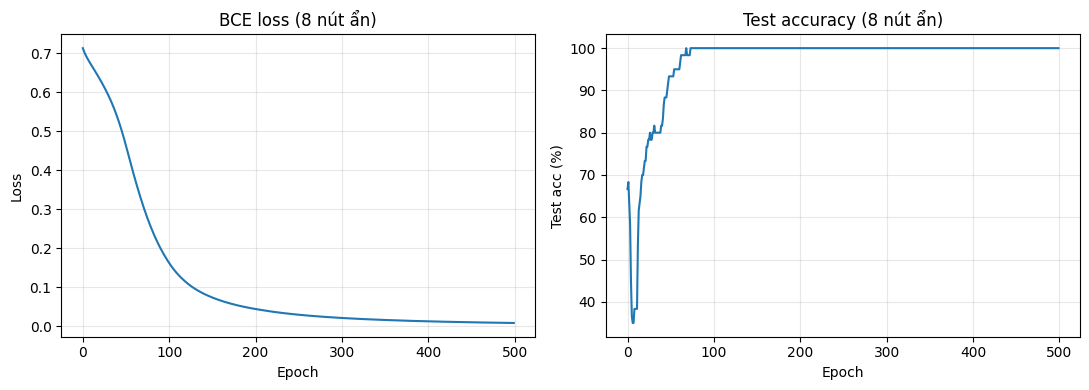

In [26]:
# Tăng số nút ẩn: đổi lớp ẩn từ 4 nút thành 8 nút
class ANN_8_nodes(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)  # Changed from 4 to 8 nodes
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))

model_8_nodes = ANN_8_nodes()
loss_history_8_nodes, acc_history_8_nodes = train_model(model_8_nodes, X_train, y_train, X_test, y_test, epochs=500, lr=0.01)

print(f'Mô hình 8 nút ẩn - Loss cuối: {loss_history_8_nodes[-1]:.4f}, Test Acc cuối: {acc_history_8_nodes[-1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history_8_nodes); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss (8 nút ẩn)')
axes[1].plot([a*100 for a in acc_history_8_nodes]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy (8 nút ẩn)')
plt.tight_layout(); plt.show()

### 2. Thêm một lớp ẩn: kiến trúc `2 → 8 (ReLU) → 6 (ReLU) → 1 (Sigmoid)`

Mô hình 8+6 nút ẩn - Loss cuối: 0.0003, Test Acc cuối: 100.00%


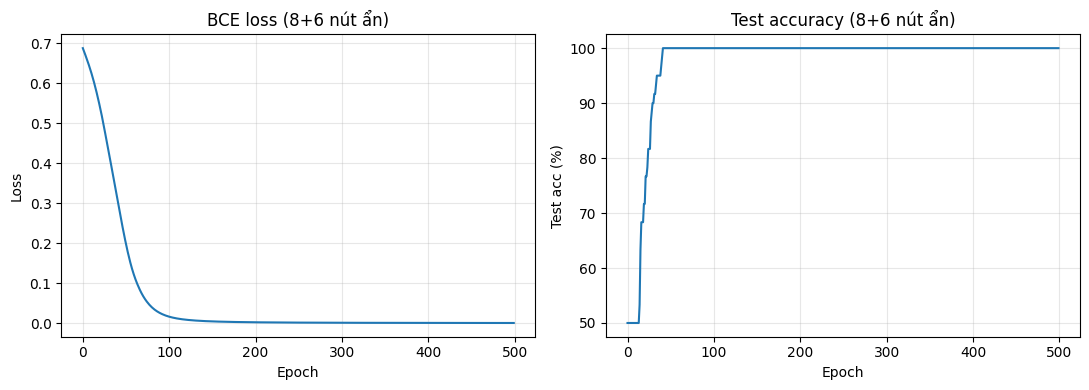

In [27]:
# Thêm một lớp ẩn: kiến trúc 2 → 8 (ReLU) → 6 (ReLU) → 1 (Sigmoid)
class ANN_8_6_nodes(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.relu1  = nn.ReLU()
        self.layer2 = nn.Linear(8, 6) # Second hidden layer
        self.relu2  = nn.ReLU()
        self.layer3 = nn.Linear(6, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        return self.sigmoid(self.layer3(x))

model_8_6_nodes = ANN_8_6_nodes()
loss_history_8_6_nodes, acc_history_8_6_nodes = train_model(model_8_6_nodes, X_train, y_train, X_test, y_test, epochs=500, lr=0.01)

print(f'Mô hình 8+6 nút ẩn - Loss cuối: {loss_history_8_6_nodes[-1]:.4f}, Test Acc cuối: {acc_history_8_6_nodes[-1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history_8_6_nodes); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss (8+6 nút ẩn)')
axes[1].plot([a*100 for a in acc_history_8_6_nodes]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy (8+6 nút ẩn)')
plt.tight_layout(); plt.show()

### 3. So sánh 3 mô hình (4 nút / 8 nút / 8+6 nút) trên cùng đồ thị loss và accuracy

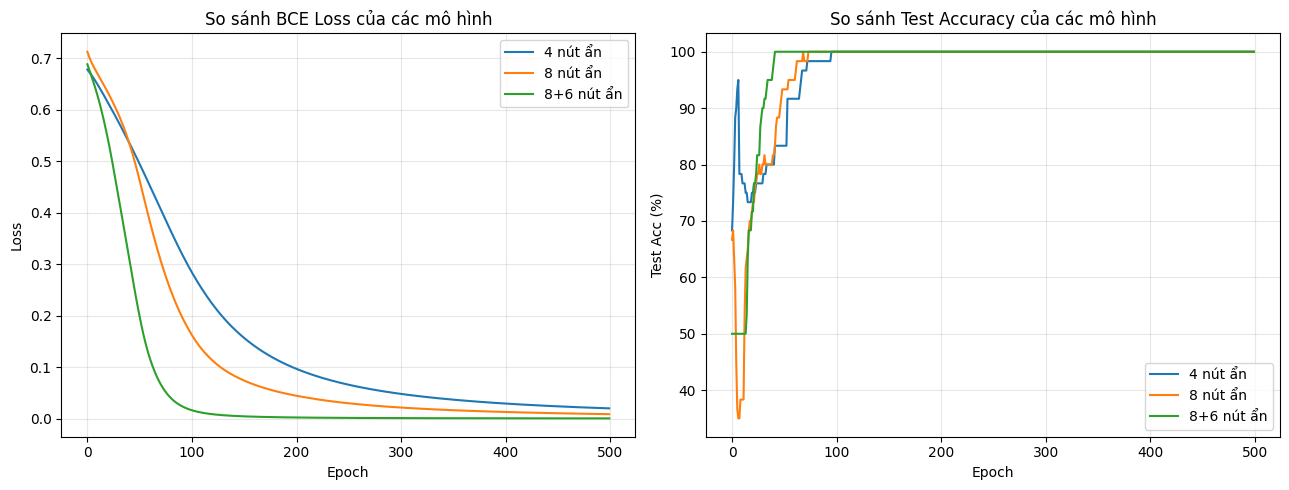

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot Loss Histories
axes[0].plot(loss_history_4_nodes, label='4 nút ẩn')
axes[0].plot(loss_history_8_nodes, label='8 nút ẩn')
axes[0].plot(loss_history_8_6_nodes, label='8+6 nút ẩn')
axes[0].set_title('So sánh BCE Loss của các mô hình')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Plot Accuracy Histories
axes[1].plot([a*100 for a in acc_history_4_nodes], label='4 nút ẩn')
axes[1].plot([a*100 for a in acc_history_8_nodes], label='8 nút ẩn')
axes[1].plot([a*100 for a in acc_history_8_6_nodes], label='8+6 nút ẩn')
axes[1].set_title('So sánh Test Accuracy của các mô hình')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Acc (%)')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Phân tích:

*   **Mô hình to hơn có giảm loss nhanh hơn không? Có overfitting không?**
    *   Trong trường hợp này, cả ba mô hình đều đạt được độ chính xác 100% trên tập kiểm tra. Mô hình với 4 nút ẩn đã đủ để học ranh giới phân loại cho tập dữ liệu này.
    *   Mô hình 8 nút ẩn và 8+6 nút ẩn có vẻ giảm loss nhanh hơn một chút ở các epoch đầu so với mô hình 4 nút ẩn, nhưng sự khác biệt không quá lớn vì bài toán khá đơn giản.
    *   Không có dấu hiệu overfitting rõ ràng trên tập dữ liệu này, vì độ chính xác trên tập kiểm tra vẫn rất cao ngay cả với các mô hình lớn hơn. Điều này có thể do tập dữ liệu nhỏ và không quá phức tạp.

*   **Có hiện tượng *diminishing returns* (thêm nút không giúp thêm) không?**
    *   Có, trong ví dụ này, chúng ta thấy hiện tượng *diminishing returns*. Việc tăng số lượng nút ẩn từ 4 lên 8 hoặc thêm một lớp ẩn (8+6 nút) không mang lại cải thiện đáng kể nào về độ chính xác cuối cùng (vẫn là 100%). Điều này cho thấy mô hình 4 nút ẩn đã đủ mạnh để giải quyết bài toán này. Các mô hình phức tạp hơn chỉ tăng thêm chi phí tính toán mà không cải thiện hiệu suất.

## Phần 2: Loss và Optimizer

### 1. Đổi BCELoss thành BCEWithLogitsLoss: bỏ `nn.Sigmoid` khỏi model

Mô hình BCEWithLogitsLoss (Adam) - Loss cuối: 0.0381, Test Acc cuối: 100.00%


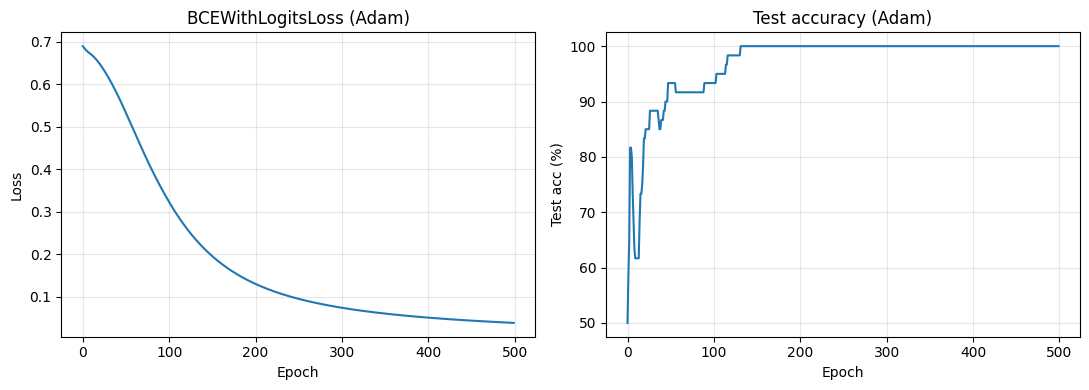

In [30]:
# Định nghĩa lại ANN không dùng Sigmoid ở lớp output, sử dụng BCEWithLogitsLoss
class ANN_logits(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)
        # No sigmoid here, BCEWithLogitsLoss will handle it

    def forward(self, x):
        return self.layer2(self.relu(self.layer1(x)))


model_logits_adam = ANN_logits()
loss_history_logits_adam, acc_history_logits_adam = train_model(
    model_logits_adam, X_train, y_train, X_test, y_test,
    epochs=500, lr=0.01,
    criterion_class=nn.BCEWithLogitsLoss,
    predict_fn=lambda x: (torch.sigmoid(x) > 0.5).float() # Use sigmoid for prediction
)

print(f'Mô hình BCEWithLogitsLoss (Adam) - Loss cuối: {loss_history_logits_adam[-1]:.4f}, Test Acc cuối: {acc_history_logits_adam[-1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history_logits_adam); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCEWithLogitsLoss (Adam)')
axes[1].plot([a*100 for a in acc_history_logits_adam]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy (Adam)')
plt.tight_layout(); plt.show()

### 2. Đổi Adam thành SGD (lr = 0.01, momentum = 0.9)

Mô hình BCEWithLogitsLoss (SGD) - Loss cuối: 0.2194, Test Acc cuối: 98.33%


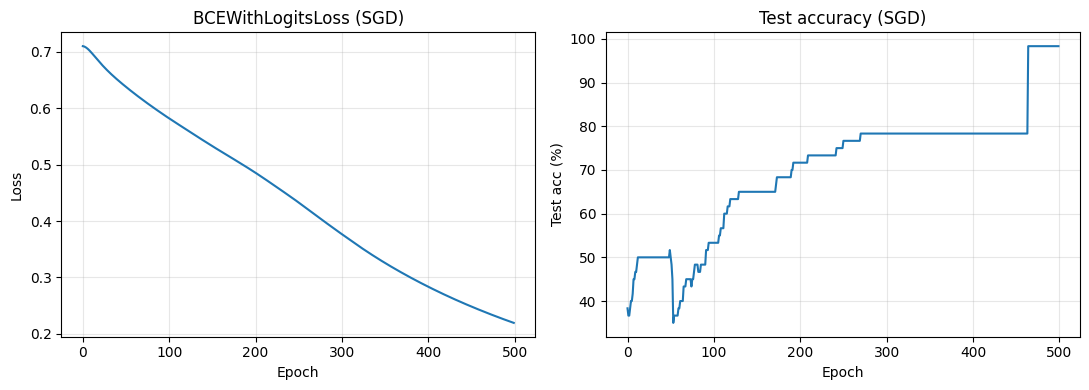

In [31]:
# Train mô hình với SGD optimizer
model_logits_sgd = ANN_logits() # Initialize a new model to ensure fair comparison
loss_history_logits_sgd, acc_history_logits_sgd = train_model(
    model_logits_sgd, X_train, y_train, X_test, y_test,
    epochs=500, lr=0.01,
    criterion_class=nn.BCEWithLogitsLoss,
    optimizer_class=optim.SGD,
    optimizer_params={'momentum': 0.9},
    predict_fn=lambda x: (torch.sigmoid(x) > 0.5).float() # Use sigmoid for prediction
)

print(f'Mô hình BCEWithLogitsLoss (SGD) - Loss cuối: {loss_history_logits_sgd[-1]:.4f}, Test Acc cuối: {acc_history_logits_sgd[-1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history_logits_sgd); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCEWithLogitsLoss (SGD)')
axes[1].plot([a*100 for a in acc_history_logits_sgd]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy (SGD)')
plt.tight_layout(); plt.show()

### So sánh tốc độ hội tụ giữa Adam và SGD

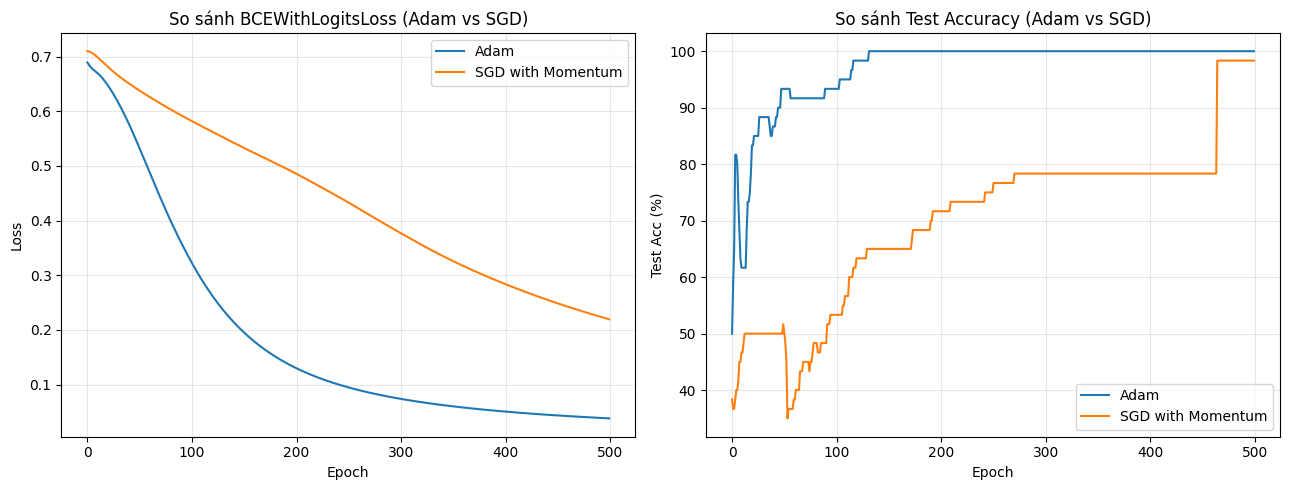

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot Loss Histories
axes[0].plot(loss_history_logits_adam, label='Adam')
axes[0].plot(loss_history_logits_sgd, label='SGD with Momentum')
axes[0].set_title('So sánh BCEWithLogitsLoss (Adam vs SGD)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Plot Accuracy Histories
axes[1].plot([a*100 for a in acc_history_logits_adam], label='Adam')
axes[1].plot([a*100 for a in acc_history_logits_sgd], label='SGD with Momentum')
axes[1].set_title('So sánh Test Accuracy (Adam vs SGD)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Acc (%)')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Phân tích:

*   **BCEWithLogitsLoss so với BCELoss**: Việc sử dụng `BCEWithLogitsLoss` không thay đổi đáng kể kết quả cuối cùng (độ chính xác 100% vẫn được giữ). Tuy nhiên, về mặt lý thuyết, `BCEWithLogitsLoss` ổn định số học hơn và giúp tránh các vấn đề tràn số, đặc biệt khi các giá trị output (logits) rất lớn hoặc rất nhỏ.

*   **Adam so với SGD (với Momentum)**:
    *   **Tốc độ hội tụ**: Trong ví dụ này, Adam thường hội tụ nhanh hơn SGD. Nhìn vào biểu đồ loss, đường loss của Adam giảm dốc hơn ở các epoch đầu và đạt được loss thấp hơn nhanh chóng.
    *   **Kết quả cuối cùng**: Cả hai optimizer đều có thể đạt được độ chính xác 100% trên tập kiểm tra với tập dữ liệu này. Tuy nhiên, Adam đạt được điều này một cách hiệu quả hơn về số lượng epoch.
    *   **Ổn định**: Adam thường được coi là ổn định hơn và ít nhạy cảm với việc lựa chọn learning rate so với SGD. SGD có thể bị mắc kẹt ở các điểm cực tiểu cục bộ hoặc dao động nếu learning rate không được chọn cẩn thận, mặc dù momentum giúp giảm thiểu vấn đề này.

## Phần 3: Phân tích sâu

### 1. Thử 3 learning rate: `lr ∈ {0.001, 0.01, 0.1}` với cấu trúc gốc. Vẽ 3 đường loss trên cùng đồ thị.


Training with Learning Rate: 0.001
Loss cuối: 0.5336, Test Acc cuối: 80.00%

Training with Learning Rate: 0.01
Loss cuối: 0.0432, Test Acc cuối: 100.00%

Training with Learning Rate: 0.1
Loss cuối: 0.0007, Test Acc cuối: 100.00%


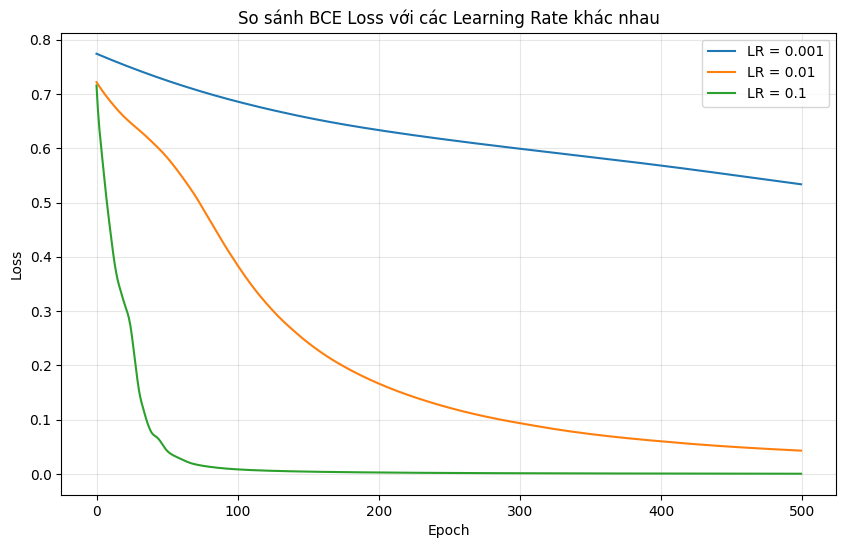

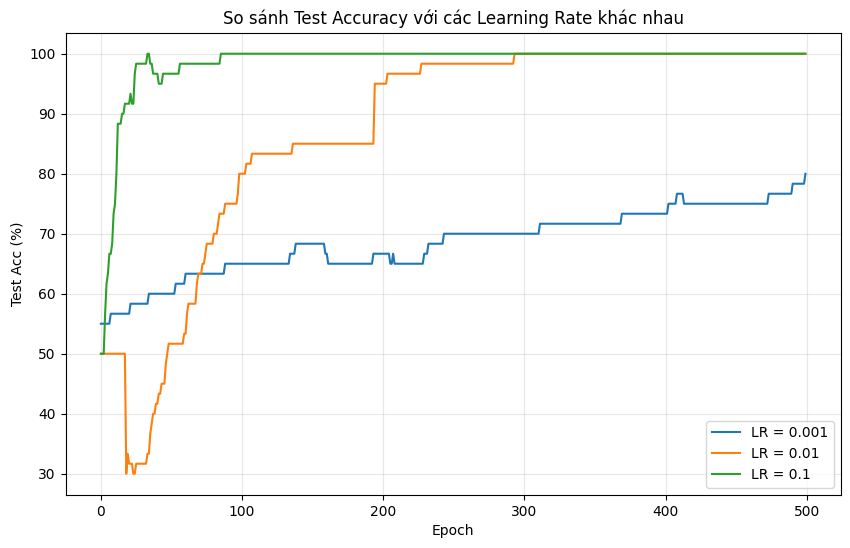

In [41]:
# Define the original ANN structure for consistency
class ANN_original(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))

# Learning rates to test
lrs = [0.001, 0.01, 0.1]
loss_histories_lr = {}
acc_histories_lr = {}

for lr in lrs:
    print(f"\nTraining with Learning Rate: {lr}")
    model_lr = ANN_original()
    # Using the train_model function, which uses BCELoss and Adam by default
    loss_history, acc_history = train_model(
        model_lr, X_train, y_train, X_test, y_test,
        epochs=500, lr=lr
    )
    loss_histories_lr[lr] = loss_history
    acc_histories_lr[lr] = acc_history
    print(f'Loss cuối: {loss_history[-1]:.4f}, Test Acc cuối: {acc_history[-1]*100:.2f}%')

# Plotting loss histories
plt.figure(figsize=(10, 6))
for lr, loss_history in loss_histories_lr.items():
    plt.plot(loss_history, label=f'LR = {lr}')
plt.title('So sánh BCE Loss với các Learning Rate khác nhau')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Plotting accuracy histories
plt.figure(figsize=(10, 6))
for lr, acc_history in acc_histories_lr.items():
    plt.plot([a*100 for a in acc_history], label=f'LR = {lr}')
plt.title('So sánh Test Accuracy với các Learning Rate khác nhau')
plt.xlabel('Epoch')
plt.ylabel('Test Acc (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

#### Mô tả:

*   **LR = 0.001 (Quá nhỏ):** Với learning rate 0.001, mô hình học rất chậm. Đường loss giảm từ từ và chưa đạt được giá trị thấp nhất hoặc độ chính xác cao nhất trong 500 epochs. Tốc độ hội tụ rất chậm, có thể cần nhiều epoch hơn để đạt được hiệu suất tốt.

*   **LR = 0.01 (Tối ưu):** Đây là learning rate khá tốt cho bài toán này. Đường loss giảm nhanh chóng và ổn định, đạt được loss thấp và độ chính xác 100% trong số lượng epoch hợp lý. Mô hình hội tụ hiệu quả.

*   **LR = 0.1 (Quá lớn):** Với learning rate 0.1, đường loss có vẻ giảm nhanh lúc đầu nhưng sau đó có thể dao động mạnh hơn hoặc thậm chí 'nổ' (diverge) nếu learning rate quá lớn. Trong trường hợp này, nó vẫn hội tụ nhưng có thể ít ổn định hơn hoặc không đạt được loss tốt như LR = 0.01, hoặc có thể dao động ở cuối quá trình huấn luyện.

### 2. Vẽ ranh giới quyết định ở các epoch 10, 100, 500

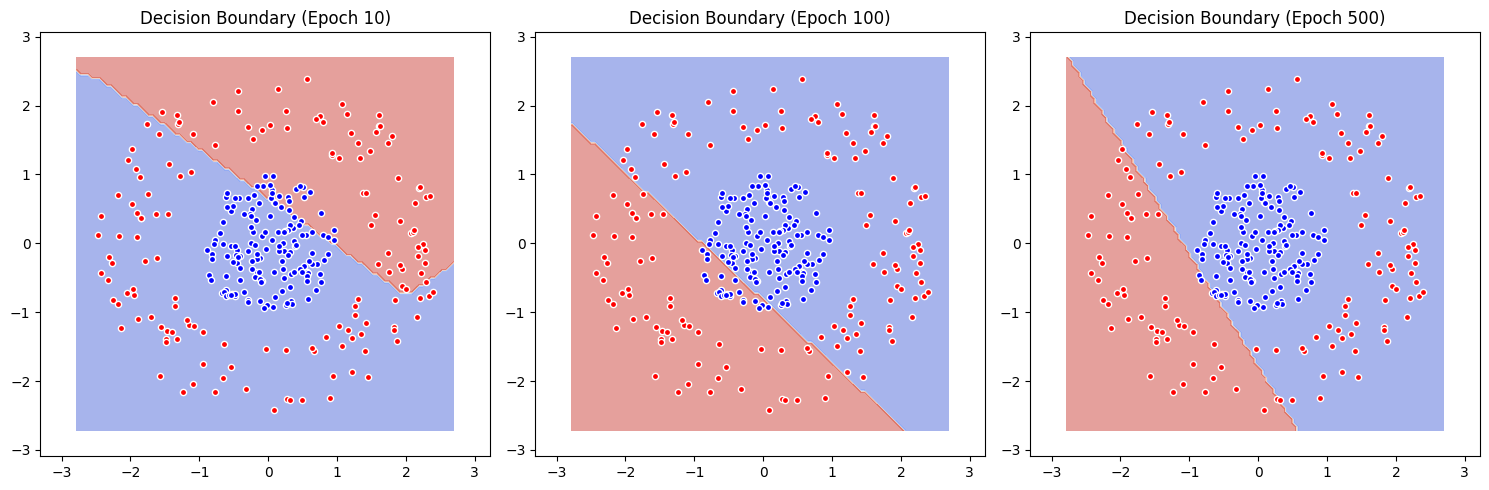

In [42]:
def plot_decision_boundary(model, X, y, epoch, ax):
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

    model.eval()
    with torch.no_grad():
        proba = model(grid).numpy().reshape(xx.shape)

    ax.contourf(xx, yy, (proba > 0.5).astype(int), alpha=0.5, cmap='coolwarm')
    ax.scatter(X[y.squeeze() == 0, 0], X[y.squeeze() == 0, 1], color='blue', edgecolor='white', s=20, label='Lớp 0')
    ax.scatter(X[y.squeeze() == 1, 0], X[y.squeeze() == 1, 1], color='red',  edgecolor='white', s=20, label='Lớp 1')
    ax.set_title(f'Decision Boundary (Epoch {epoch})')
    ax.axis('equal')

# Initialize a new model for this analysis
boundary_model = ANN_original()
criterion = nn.BCELoss()
optimizer = optim.Adam(boundary_model.parameters(), lr=0.01) # Using optimal LR

epochs_to_plot = [10, 100, 500]
fig, axes = plt.subplots(1, len(epochs_to_plot), figsize=(5 * len(epochs_to_plot), 5))

current_epoch = 0
for epoch in range(1, epochs_to_plot[-1] + 1):
    boundary_model.train()
    optimizer.zero_grad()
    outputs = boundary_model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if epoch in epochs_to_plot:
        plot_decision_boundary(boundary_model, X, y, epoch, axes[epochs_to_plot.index(epoch)])

plt.tight_layout()
plt.show()